# PCA Dynamic NWB-Only (v2)

NWB-only pipeline. No `df_units.json` or `df_stim.json` is needed.


### Suggestions on how to improve Notebook
1. okay how can i now run each of these PCAs on a per probe level. For example in the df_units there is the column header "probe", values for "probe" can be either (A,B,C,D,E,F). 

### Imports


In [13]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pynwb import NWBHDF5IO
from scipy.ndimage import gaussian_filter1d

sns.set_context("talk")
sns.set_style("white")
warnings.filterwarnings("ignore")


### NWB Loader


In [14]:
class nwb_loader:
    def __init__(self, nwb_path):
        self.nwb_path = str(nwb_path)
        self.io = None
        self.nwb = None
        self.load_nwb()

    def load_nwb(self):
        self.io = NWBHDF5IO(self.nwb_path, "r", load_namespaces=True)
        self.nwb = self.io.read()
        return self.nwb

    def trials(self):
        return self.nwb.trials.to_dataframe() if self.nwb.trials is not None else pd.DataFrame()

    def units(self):
        return self.nwb.units.to_dataframe() if self.nwb.units is not None else pd.DataFrame()

    def optogenetics_states(self):
        if "optogenetics_states" in self.nwb.intervals:
            return self.nwb.intervals["optogenetics_states"].to_dataframe()
        return pd.DataFrame()

    def close(self):
        try:
            if self.io is not None:
                self.io.close()
        except Exception:
            pass


### Config


In [15]:
NWB_PATH = Path(r"G:\Grant\neuropixels\nwb\Reach15")

WINDOW_START_S = -0.5
WINDOW_END_S = 3.5
BIN_SIZE_S = 0.05
N_COMPONENTS = 12
SMOOTH_SIGMA = 2

LABEL_MODE = "block"   # 'block' or 'stimulus'
EVENT_INCLUDE = None    # e.g., ['reach'] or None

# Memory safety controls
MAX_EVENTS = 5000                 # hard cap on analyzed events (None disables)
EVENT_SUBSAMPLE_MODE = "uniform"  # 'uniform' or 'first'
MAX_TENSOR_GB = 8.0               # abort if trials tensor estimate exceeds this

PROBE_FILTER = None     # 'A'..'F' or None
KSLABEL_FILTER = None   # 'good'/'mua' or 2/1 or None
UNIT_FILTER_QUERY = None
MAX_UNITS = None

OUT_DIR = Path.cwd() / "extra_files"
OUT_DIR.mkdir(parents=True, exist_ok=True)


### Helpers


In [16]:
def resolve_nwb_path(p: Path) -> Path:
    if not p.exists():
        raise FileNotFoundError(f"NWB path not found: {p}")
    if p.is_file():
        return p
    nwb_files = sorted(list(p.rglob("*.nwb")))
    if len(nwb_files) == 1:
        return nwb_files[0]
    if len(nwb_files) > 1:
        raise ValueError("Multiple NWB files found. Point NWB_PATH to one file.")
    files = [x for x in p.iterdir() if x.is_file()]
    if len(files) == 1:
        return files[0]
    raise ValueError("Could not resolve a unique NWB file path.")


def zscore_rows(x: np.ndarray) -> np.ndarray:
    ss = StandardScaler(with_mean=True, with_std=True)
    return ss.fit_transform(x.T).T


def choose_event_time_col(df: pd.DataFrame) -> str:
    for c in ["start_time", "time", "event_time", "timestamps"]:
        if c in df.columns:
            return c
    raise ValueError(f"No event-time column found in trials table. Columns: {list(df.columns)}")


def normalize_kslabel(v):
    if pd.isna(v):
        return np.nan
    try:
        iv = int(float(v))
        if iv == 2:
            return "good"
        if iv == 1:
            return "mua"
    except Exception:
        pass
    s = str(v).strip().lower()
    if s in {"2", "good", "single", "singleunit", "single_unit"}:
        return "good"
    if s in {"1", "mua", "multi", "multiunit", "multi_unit"}:
        return "mua"
    return s


def infer_is_opto(df_trials: pd.DataFrame) -> pd.Series:
    if "optogenetics_LED_state" in df_trials.columns:
        c = df_trials["optogenetics_LED_state"]
        if pd.api.types.is_numeric_dtype(c):
            return pd.to_numeric(c, errors="coerce").fillna(0) > 0
        return c.astype(str).str.lower().isin(["1", "true", "on", "high"])
    if "stimulus" in df_trials.columns:
        s = df_trials["stimulus"].astype(str).str.lower()
        return s.str.contains("opto|laser|led|stim", regex=True)
    return pd.Series([False] * len(df_trials), index=df_trials.index)


def build_block_labels(is_opto: pd.Series) -> pd.DataFrame:
    is_opto = is_opto.astype(bool).reset_index(drop=True)
    block_id = (is_opto != is_opto.shift(1, fill_value=is_opto.iloc[0])).cumsum()

    mapping = {}
    seen_opto = False
    opto_k = 1
    wash_k = 1
    for b in block_id.unique():
        state = bool(is_opto[block_id == b].iloc[0])
        if state:
            mapping[b] = f"opto_epoch_{opto_k}"
            opto_k += 1
            seen_opto = True
        else:
            mapping[b] = "baseline" if not seen_opto else f"washout_epoch_{wash_k}"
            if seen_opto:
                wash_k += 1

    return pd.DataFrame({"block_id": block_id, "is_opto": is_opto, "block_label": block_id.map(mapping)})


def find_probe_col(df: pd.DataFrame):
    for c in ["probe", "probe_name", "probe_id", "probe_letter", "electrode_group"]:
        if c in df.columns:
            return c
    return None


def find_kslabel_col(df: pd.DataFrame):
    for c in ["KSLabel", "kslabel", "ks_label", "label", "quality"]:
        if c in df.columns:
            return c
    return None


def pick_region_col(df: pd.DataFrame):
    for c in ["brain_region", "location", "region", "acronym", "structure", "ccf_acronym"]:
        if c in df.columns:
            return c
    return None


### Load bombcell data 

In [17]:
# set root bombcell path 
root_bc_path = fr"H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_{probe}\bombcell\Probe_{probe}_quality_metrics.csv"

quality_metrics_path = r"H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_A\bombcell\Probe_A_quality_metrics.csv"
# load csv file
quality_metrics = pd.read_csv(quality_metrics_path)
quality_metrics

NameError: name 'probe' is not defined

### Load NWB Tables


In [18]:
resolved_nwb = resolve_nwb_path(NWB_PATH)
mouse = nwb_loader(resolved_nwb)

df_trials = mouse.trials().reset_index(drop=True)
df_units = mouse.units().reset_index(drop=True)

print("NWB:", resolved_nwb)
print("trials shape:", df_trials.shape)
print("units shape:", df_units.shape)
print("trials columns:", list(df_trials.columns))
print("units columns:", list(df_units.columns))


NWB: G:\Grant\neuropixels\nwb\Reach15
trials shape: (1352824, 4)
units shape: (4600, 9)
trials columns: ['start_time', 'stop_time', 'stimulus', 'optogenetics_LED_state']
units columns: ['depth', 'xpos', 'ypos', 'label', 'KSlabel', 'KSamplitude', 'KScontamination', 'probe', 'spike_times']


In [66]:
# print unique names inside stimulus
unit_probes = np.array(df_units.probe.unique())
unit_headers = df_units.columns.tolist()
df_units_dic = {}

print('===== Total units Per Probe ====')
for probe in unit_probes:
    df = df_units[df_units['probe']==probe]
    print(f'{probe}: ', len(df))
    df_units_dic[probe] = df
print('\n')
probe_letter = 'A'
print(f'Comapre with Above: total units in probe {probe_letter}: ', len(df_units_dic[probe_letter]))
df_units_dic[probe_letter][0:5]

===== Total units Per Probe ====
A:  554
B:  1316
C:  355
D:  820
E:  864
F:  691


Comapre with Above: total units in probe A:  554


,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,spike_times
0,3120.0,277.0,30.0,0,2,9.5,14.5,A,"[9938.427594575005, 9938.443329123113, 9938.44..."
1,3120.0,277.0,30.0,0,2,10.3,17.2,A,"[9938.363989665882, 9938.408826460065, 9938.42..."
2,3120.0,59.0,30.0,0,1,9.0,0.0,A,"[9938.135738714089, 9939.27045963741, 9940.801..."
3,2775.0,27.0,375.0,0,2,8.5,0.0,A,"[9938.897430842511, 9940.381573391209, 9941.04..."
4,2745.0,59.0,405.0,0,2,9.1,7.4,A,"[9938.29451763671, 9938.519134975282, 9938.609..."


### Load bombcell Results

In [63]:
qm_df_list = []
qm_dic = {}
# set root bombcell path 
for probe in unit_probes:
    print(f'Loading Probe {probe} quality_metrics.csv')
    bc_qm_path = fr"H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_{probe}\bombcell\Probe_{probe}_quality_metrics.csv"
    # print('      ',bc_qm_path)
    qm_df = pd.read_csv(bc_qm_path)
    qm_df_list.append(qm_df)
    qm_dic[probe] = qm_df

### Look at one of the probes quality_metrics.csv from the dic
probe_letter = "A"
qm_dic[probe_letter]

Loading Probe A quality_metrics.csv
Loading Probe B quality_metrics.csv
Loading Probe C quality_metrics.csv
Loading Probe D quality_metrics.csv
Loading Probe E quality_metrics.csv
Loading Probe F quality_metrics.csv


,Bombcell_unit_type,bc_roiLabel,cluster_id,phy_clusterID,nSpikes,nPeaks,nTroughs,waveformDuration_peakTrough,spatialDecaySlope,waveformBaselineFlatness,...,maxDriftEstimate,cumDriftEstimate,rawAmplitude,signalToNoiseRatio,isolationDistance,Lratio,silhouetteScore,useTheseTimesStart,useTheseTimesStop,maxChannels
0,NOISE,IN_ROI,0,0,14579.0,3.0,2.0,933.333333,0.005549,0.511003,...,29.717560,866.206142,186.966594,13.572736,NaN,NaN,NaN,0.000467,9295.177067,52
1,NOISE,IN_ROI,1,1,35469.0,3.0,2.0,866.666667,0.005141,0.403423,...,93.164818,230.102596,230.097000,16.701146,NaN,NaN,NaN,0.000467,9295.177067,52
2,NOISE,IN_ROI,2,2,176.0,1.0,1.0,700.000000,-0.100000,0.155820,...,4.297394,11.051605,160.051301,21.050941,NaN,NaN,NaN,0.000467,9295.177067,5
3,NOISE,IN_ROI,3,3,386.0,1.0,1.0,333.333333,0.008312,0.064297,...,403.393829,2420.727112,273.349331,42.479090,NaN,NaN,NaN,0.000467,9295.177067,98
4,NOISE,IN_ROI,4,4,10164.0,1.0,1.0,366.666667,0.005716,0.081563,...,614.671204,24995.096527,214.158510,28.683601,NaN,NaN,NaN,0.000467,9295.177067,103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,NOISE,IN_ROI,549,549,21787.0,3.0,2.0,800.000000,0.001556,0.386106,...,13.546143,250.866943,51.410105,5.717207,NaN,NaN,NaN,0.000467,9295.177067,265
550,NOISE,IN_ROI,550,550,33577.0,2.0,2.0,700.000000,0.002063,0.346240,...,2849.913330,10085.687134,36.391772,11.665791,NaN,NaN,NaN,0.000467,9295.177067,265
551,NOISE,IN_ROI,551,551,967.0,1.0,1.0,700.000000,0.004852,0.054340,...,125.027832,1649.666748,416.368065,35.135306,NaN,NaN,NaN,0.000467,9295.177067,260
552,NOISE,IN_ROI,552,552,68.0,2.0,1.0,666.666667,0.005006,0.253433,...,57.330322,287.158936,50.463481,14.543859,NaN,NaN,NaN,0.000467,9295.177067,273


### Verify the bombcell quality metrics dictonary matches the number of untis in df_units on a per probe basis

In [67]:
print('===== Total units Per Probe ====')
for probe in unit_probes:
    df = df_units[df_units['probe']==probe]
    df_units_len = len(df)
    qm_dic_len = len(qm_dic[probe])
    if df_units_len == qm_dic_len:
        print(f'df_units {probe}: ', df_units_len)
        print(f'qm_dic_len {probe}: ', qm_dic_len)
        print('------------------------')
    else:
        print(f'**qualitt_metrics.csv and df_units for Probe {probe} do NOT have same number of units***')
        print(f'df_units {probe}: ', df_units_len)
        print(f'qm_dic_len {probe}: ', qm_dic_len)
        print('------------------------')


===== Total units Per Probe ====
df_units A:  554
qm_dic_len A:  554
------------------------
df_units B:  1316
qm_dic_len B:  1316
------------------------
df_units C:  355
qm_dic_len C:  355
------------------------
df_units D:  820
qm_dic_len D:  820
------------------------
df_units E:  864
qm_dic_len E:  864
------------------------
df_units F:  691
qm_dic_len F:  691
------------------------


### Combine Bombcell quality metrics columns with df_units 

In [ ]:
df1 = df1.reset_index(drop=True)
df2 = df2.reset_index(drop=True)
maxChannels

In [76]:
merged_dic = {}
print('===== Total units Per Probe ====')
for probe in unit_probes:
    df_units_merged = df_units_dic[probe]
    df_qm = qm_dic[probe]
    df_units_len = len(df_units_merged)
    qm_len = len(df_qm)
    if df_units_len == qm_len:
        # df_units = df_units.reset_index(drop=True)
        # df_qm = df_qm.reset_index(drop=True)
        df_units_merged['bc_label'] = df_qm['Bombcell_unit_type']
        df_units_merged['in_brainRegion'] = df_qm['bc_roiLabel']
        df_units_merged['cluster_id'] = df_qm['cluster_id']
        df_units_merged['nSpikes'] = df_qm['nSpikes']
        df_units_merged['maxDriftEstimate'] = df_qm['maxDriftEstimate']
        df_units_merged['maxChannels'] = df_qm['maxChannels']
        merged_dic[probe] = df_units_merged
        print(f'probe {probe} \n SUCCESSFULLY Merged quality_metrics.csv with df_units ')
        print('------------------------')
    else:
        print(f'\nERROR probe {probe}\n')
        print(f'**qualitt_metrics.csv and df_units for Probe {probe} do NOT have same number of units***')
        print(f'df_units {probe}: ', df_units_len)
        print(f'qm_dic_len {probe}: ', qm_len)
        print('------------------------')

===== Total units Per Probe ====
probe A 
 SUCCESSFULLY Merged quality_metrics.csv with df_units 
------------------------
probe B 
 SUCCESSFULLY Merged quality_metrics.csv with df_units 
------------------------
probe C 
 SUCCESSFULLY Merged quality_metrics.csv with df_units 
------------------------
probe D 
 SUCCESSFULLY Merged quality_metrics.csv with df_units 
------------------------
probe E 
 SUCCESSFULLY Merged quality_metrics.csv with df_units 
------------------------
probe F 
 SUCCESSFULLY Merged quality_metrics.csv with df_units 
------------------------


### Verify the new merged_dic has data from quality_metrics.csv and values from df_units

In [79]:
probe_letter = 'A'
merged_dic[probe_letter]

,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,spike_times,bc_label,in_brainRegion,cluster_id,nSpikes,maxDriftEstimate,maxChannels
0,3120.0,277.0,30.0,0,2,9.5,14.5,A,"[9938.427594575005, 9938.443329123113, 9938.44...",NOISE,IN_ROI,0,14579.0,29.717560,52
1,3120.0,277.0,30.0,0,2,10.3,17.2,A,"[9938.363989665882, 9938.408826460065, 9938.42...",NOISE,IN_ROI,1,35469.0,93.164818,52
2,3120.0,59.0,30.0,0,1,9.0,0.0,A,"[9938.135738714089, 9939.27045963741, 9940.801...",NOISE,IN_ROI,2,176.0,4.297394,5
3,2775.0,27.0,375.0,0,2,8.5,0.0,A,"[9938.897430842511, 9940.381573391209, 9941.04...",NOISE,IN_ROI,3,386.0,403.393829,98
4,2745.0,59.0,405.0,0,2,9.1,7.4,A,"[9938.29451763671, 9938.519134975282, 9938.609...",NOISE,IN_ROI,4,10164.0,614.671204,103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549,90.0,809.0,3060.0,0,1,10.1,49.5,A,"[9938.42912802667, 9939.349965773692, 9939.545...",NOISE,IN_ROI,549,21787.0,13.546143,265
550,90.0,809.0,3060.0,0,1,10.1,36.0,A,"[9938.435628528883, 9938.436628606056, 9938.45...",NOISE,IN_ROI,550,33577.0,2849.913330,265
551,120.0,777.0,3030.0,0,2,15.0,0.0,A,"[9939.710326923783, 9996.315897808852, 10004.7...",NOISE,IN_ROI,551,967.0,125.027832,260
552,30.0,809.0,3120.0,0,2,9.1,0.0,A,"[9961.076493597408, 9966.67352562832, 9967.364...",NOISE,IN_ROI,552,68.0,57.330322,273


### Build Event Table


In [78]:
if df_trials.empty:
    raise ValueError("NWB trials table is empty.")

time_col = choose_event_time_col(df_trials)
stim_df = df_trials.copy()
stim_df["event_time_s"] = pd.to_numeric(stim_df[time_col], errors="coerce")
stim_df = stim_df.dropna(subset=["event_time_s"]).sort_values("event_time_s").reset_index(drop=True)

# Optional event inclusion by stimulus token
if EVENT_INCLUDE is not None and "stimulus" in stim_df.columns:
    ss = stim_df["stimulus"].astype(str).str.lower()
    m = pd.Series(False, index=stim_df.index)
    for token in EVENT_INCLUDE:
        m = m | ss.str.contains(str(token).lower(), regex=False)
    stim_df = stim_df[m].reset_index(drop=True)

# If still huge, downsample safely for PCA
n_before = len(stim_df)
if MAX_EVENTS is not None and n_before > MAX_EVENTS:
    if EVENT_SUBSAMPLE_MODE == "first":
        keep_idx = np.arange(MAX_EVENTS)
    else:
        keep_idx = np.linspace(0, n_before - 1, MAX_EVENTS, dtype=int)
    stim_df = stim_df.iloc[keep_idx].reset_index(drop=True)
    print(f"Downsampled events: {n_before} -> {len(stim_df)} (mode={EVENT_SUBSAMPLE_MODE})")

blk = build_block_labels(infer_is_opto(stim_df))
stim_df = pd.concat([stim_df, blk], axis=1)
stim_df["trial_index"] = np.arange(len(stim_df), dtype=int)
stim_df["label"] = stim_df["stimulus"].astype(str) if (LABEL_MODE == "stimulus" and "stimulus" in stim_df.columns) else stim_df["block_label"].astype(str)

print(stim_df[["trial_index", "event_time_s", "label", "is_opto"]].head(10))
print("\nLabel counts:")
print(stim_df["label"].value_counts())
print(f"\nTotal events used for PCA: {len(stim_df)}")


Downsampled events: 1352824 -> 5000 (mode=uniform)
   trial_index  event_time_s     label  is_opto
0            0  10028.508867  baseline    False
1            1  10030.309167  baseline    False
2            2  10032.116133  baseline    False
3            3  10033.916433  baseline    False
4            4  10035.723433  baseline    False
5            5  10037.530367  baseline    False
6            6  10039.330700  baseline    False
7            7  10041.137700  baseline    False
8            8  10042.938000  baseline    False
9            9  10044.744967  baseline    False

Label counts:
label
baseline           3424
washout_epoch_1    1497
washout_epoch_2      77
opto_epoch_1          1
opto_epoch_2          1
Name: count, dtype: int64

Total events used for PCA: 5000


### Build Unit Metadata + Filters


In [7]:
if df_units.empty:
    raise ValueError("NWB units table is empty.")
if "spike_times" not in df_units.columns:
    raise ValueError("NWB units table missing spike_times column.")

unit_meta = df_units.copy().reset_index(drop=True)
if "unit_id" not in unit_meta.columns:
    unit_meta["unit_id"] = unit_meta.index.astype(int)

probe_col = find_probe_col(unit_meta)
if PROBE_FILTER is not None:
    if probe_col is None:
        raise ValueError("PROBE_FILTER set but no probe column found.")
    pnorm = unit_meta[probe_col].astype(str).str.strip().str.upper().str[0]
    unit_meta = unit_meta[pnorm == str(PROBE_FILTER).strip().upper()].reset_index(drop=True)

ks_col = find_kslabel_col(unit_meta)
if KSLABEL_FILTER is not None:
    if ks_col is None:
        raise ValueError("KSLABEL_FILTER set but no KS label column found.")
    target = normalize_kslabel(KSLABEL_FILTER)
    unit_meta = unit_meta[unit_meta[ks_col].map(normalize_kslabel) == target].reset_index(drop=True)

if UNIT_FILTER_QUERY:
    unit_meta = unit_meta.query(UNIT_FILTER_QUERY).reset_index(drop=True)

if MAX_UNITS is not None:
    unit_meta = unit_meta.iloc[:MAX_UNITS].reset_index(drop=True)

spike_times_by_unit = [np.asarray(x, dtype=float) for x in unit_meta["spike_times"].values]
if len(spike_times_by_unit) == 0:
    raise ValueError("No units left after filtering.")

print("Final units:", len(spike_times_by_unit))
print(unit_meta.head(3))


Final units: 4600
    depth   xpos  ypos  label  KSlabel  KSamplitude  KScontamination probe  \
0  3120.0  277.0  30.0      0        2          9.5             14.5     A   
1  3120.0  277.0  30.0      0        2         10.3             17.2     A   
2  3120.0   59.0  30.0      0        1          9.0              0.0     A   

                                         spike_times  unit_id  
0  [9938.427594575005, 9938.443329123113, 9938.44...        0  
1  [9938.363989665882, 9938.408826460065, 9938.42...        1  
2  [9938.135738714089, 9939.27045963741, 9940.801...        2  


### Bin Spikes Around Events


In [8]:
def bin_spikes_around_events(spike_times_list, event_times_s, win_start_s, win_end_s, bin_size_s, max_tensor_gb=8.0):
    edges = np.arange(win_start_s, win_end_s + bin_size_s, bin_size_s)
    n_bins = len(edges) - 1
    n_trials = len(event_times_s)
    n_units = len(spike_times_list)

    est_bytes = n_trials * n_units * n_bins * np.dtype(np.float32).itemsize
    est_gb = est_bytes / (1024 ** 3)
    print(f"Requested tensor shape=({n_trials}, {n_units}, {n_bins}) est_mem={est_gb:.2f} GB")

    if est_gb > max_tensor_gb:
        raise MemoryError(
            f"Estimated tensor memory {est_gb:.2f} GB exceeds MAX_TENSOR_GB={max_tensor_gb}. "
            "Reduce events (EVENT_INCLUDE / MAX_EVENTS), reduce units (filters), or increase BIN_SIZE_S."
        )

    X = np.zeros((n_trials, n_units, n_bins), dtype=np.float32)

    for u, st in enumerate(spike_times_list):
        if st.size == 0:
            continue
        for t, t0 in enumerate(event_times_s):
            i0 = np.searchsorted(st, t0 + win_start_s, side="left")
            i1 = np.searchsorted(st, t0 + win_end_s, side="right")
            rel = st[i0:i1] - t0
            if rel.size:
                counts, _ = np.histogram(rel, bins=edges)
                X[t, u, :] = counts / bin_size_s

    return X, edges[:-1]

trials, time = bin_spikes_around_events(
    spike_times_by_unit,
    stim_df["event_time_s"].to_numpy(dtype=float),
    WINDOW_START_S,
    WINDOW_END_S,
    BIN_SIZE_S,
    max_tensor_gb=MAX_TENSOR_GB,
)
print("trials shape:", trials.shape, "(n_trials, n_units, n_bins)")


Requested tensor shape=(5000, 4600, 80) est_mem=6.85 GB
trials shape: (5000, 4600, 80) (n_trials, n_units, n_bins)


### Trial-Level PCA


Trial PCA EVR (first 5): [0.4038 0.1106 0.0632 0.0474 0.0388]


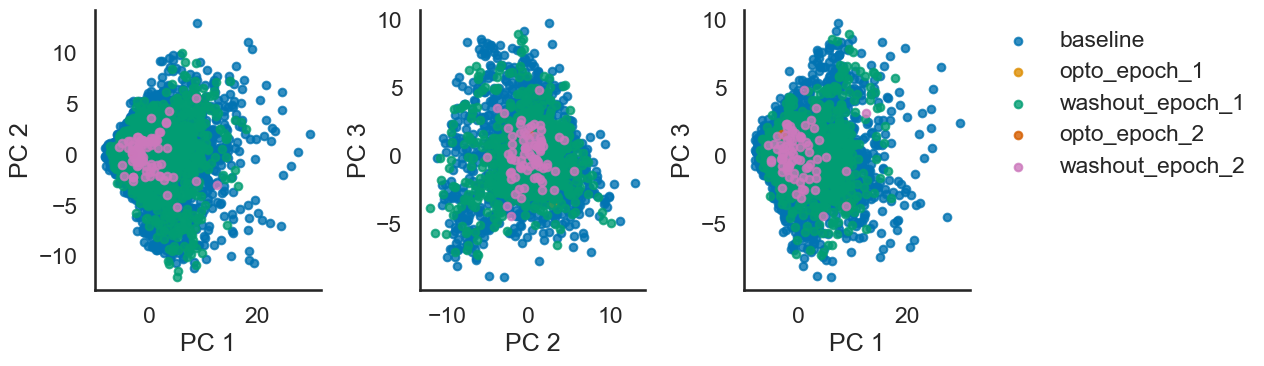

In [9]:
trial_type = stim_df["label"].to_numpy()
trial_types = pd.unique(trial_type)
t_type_ind = [np.where(trial_type == t)[0] for t in trial_types]

in_task = (time >= 0.0) & (time < (WINDOW_END_S - BIN_SIZE_S))
if in_task.sum() == 0:
    raise ValueError("No bins in in-task window.")

X_trial = np.vstack([trials[i, :, in_task].mean(axis=1) for i in range(trials.shape[0])]).T
X_trial_z = zscore_rows(X_trial)
pca_trial = PCA(n_components=min(N_COMPONENTS, X_trial_z.shape[0], X_trial_z.shape[1]))
Xp = pca_trial.fit_transform(X_trial_z.T).T

print("Trial PCA EVR (first 5):", np.round(pca_trial.explained_variance_ratio_[:5], 4))

projections = [(0, 1), (1, 2), (0, 2)]
pal = sns.color_palette("colorblind", len(trial_types))
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (i, j) in zip(axes, projections):
    for k, t in enumerate(trial_types):
        idx = t_type_ind[k]
        ax.scatter(Xp[i, idx], Xp[j, idx], s=30, alpha=0.8, color=pal[k], label=str(t))
    ax.set_xlabel(f"PC {i+1}")
    ax.set_ylabel(f"PC {j+1}")
axes[-1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()


### Trajectory PCA


Trajectory PCA EVR (first 5): [0.2417 0.0726 0.0503 0.0336 0.0182]


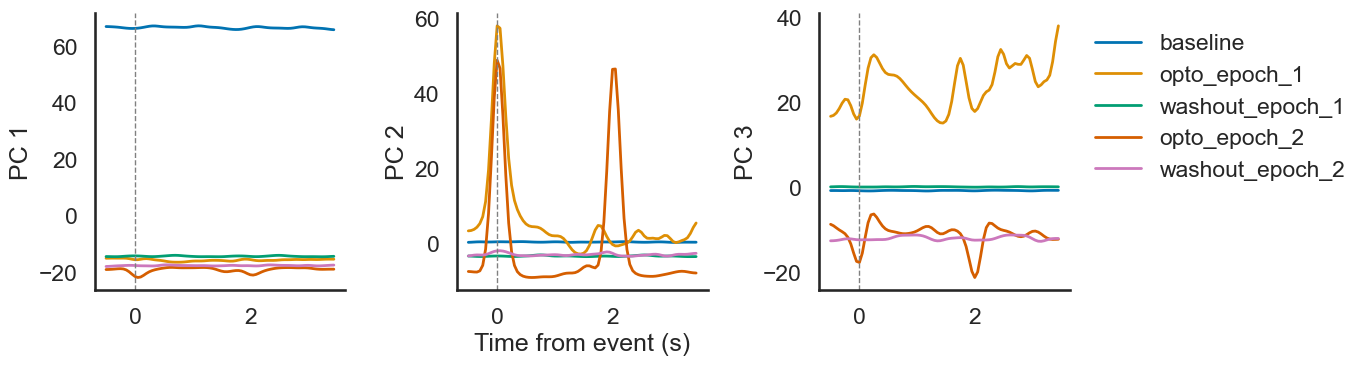

In [10]:
trial_averages = []
kept_labels = []
for t, idx in zip(trial_types, t_type_ind):
    if len(idx) > 0:
        trial_averages.append(trials[idx].mean(axis=0))
        kept_labels.append(t)

if len(trial_averages) < 2:
    raise ValueError("Need >=2 labels for trajectory PCA.")

Xa = np.hstack(trial_averages)
Xa_z = zscore_rows(Xa)
pca_traj = PCA(n_components=min(N_COMPONENTS, Xa_z.shape[0], Xa_z.shape[1]))
Xa_p = pca_traj.fit_transform(Xa_z.T).T

print("Trajectory PCA EVR (first 5):", np.round(pca_traj.explained_variance_ratio_[:5], 4))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
n_bins = trials.shape[2]
for comp in range(min(3, Xa_p.shape[0])):
    ax = axes[comp]
    for k, lbl in enumerate(kept_labels):
        s = k * n_bins
        e = (k + 1) * n_bins
        x = Xa_p[comp, s:e]
        if SMOOTH_SIGMA and SMOOTH_SIGMA > 0:
            x = gaussian_filter1d(x, sigma=SMOOTH_SIGMA)
        ax.plot(time, x, lw=2, color=pal[k], label=str(lbl))
    ax.axvline(0, color="gray", ls="--", lw=1)
    ax.set_ylabel(f"PC {comp+1}")

axes[1].set_xlabel("Time from event (s)")
axes[-1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()


### Optional Region-Level PCA


In [11]:
region_col = pick_region_col(unit_meta)
if region_col is None:
    print("No region column found; skipping region-level PCA.")
else:
    rs = unit_meta[region_col].astype(str).fillna("unknown")
    keep_regions = rs.value_counts()
    keep_regions = keep_regions[keep_regions >= 3].index

    if len(keep_regions) < 2:
        print("Not enough regions with >=3 units; skipping.")
    else:
        region_ids = [np.where(rs.values == r)[0] for r in keep_regions]
        region_trials = np.stack([trials[:, ridx, :].mean(axis=1) for ridx in region_ids], axis=1)

        X_region = np.vstack([region_trials[i, :, in_task].mean(axis=1) for i in range(region_trials.shape[0])]).T
        X_region_z = zscore_rows(X_region)
        pca_region = PCA(n_components=min(6, X_region_z.shape[0], X_region_z.shape[1]))
        Xrp = pca_region.fit_transform(X_region_z.T).T

        print("Region PCA EVR (first 5):", np.round(pca_region.explained_variance_ratio_[:5], 4))

        plt.figure(figsize=(5, 4))
        for k, t in enumerate(trial_types):
            idx = t_type_ind[k]
            plt.scatter(Xrp[0, idx], Xrp[1, idx], s=28, alpha=0.8, color=pal[k], label=str(t))
        plt.xlabel("PC 1")
        plt.ylabel("PC 2")
        plt.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
        sns.despine()
        plt.tight_layout()
        plt.show()


No region column found; skipping region-level PCA.


### Save Outputs


In [ ]:
np.save(OUT_DIR / "nwb_only_trials_fr.npy", trials)
np.save(OUT_DIR / "nwb_only_trial_pca_scores.npy", Xp)
np.save(OUT_DIR / "nwb_only_traj_pca_scores.npy", Xa_p)
stim_df.to_csv(OUT_DIR / "nwb_only_trial_table.csv", index=False)
unit_meta.to_csv(OUT_DIR / "nwb_only_unit_meta.csv", index=False)

print("Saved files to:", OUT_DIR)
mouse.close()
